# Grupo 7
MARCIO RIBEIRO JULIÃO,
LUCAS PEREIRA CANUTO,
MARCELO FRESCHI DE OLIVEIRA CORREIA MENEZES,
CAIO ACAYABA FURTADO,
GUSTAVO CARDOSO SOUSA.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
df = pd.read_csv(
    "vendas_rede_varejo.csv",
    sep=";",
    decimal=",",
    parse_dates=["data_venda"],
)

# Criar colunas de lucro e margem
df["lucro"] = df["valor_total"] - df["custo_total"]
df["margem_lucro"] = df["lucro"] / df["valor_total"]

df.head()

,data_venda,canal_venda,regiao,categoria_produto,quantidade,preco_unitario,valor_total,custo_total,campanha,satisfacao_cliente,lucro,margem_lucro
0,2025-04-13,App,Norte,Eletrodomésticos,16,1318.49,21095.84,11291.56,Natal,6.10,9804.28,0.46
1,2025-12-15,App,Sudeste,Beleza,19,561.28,10664.32,6138.38,Aniversário da Loja,8.10,4525.94,0.42
2,2025-09-28,Loja Física,Sudeste,Moda,14,2473.79,34633.06,26883.11,Black Friday,8.00,7749.95,0.22
3,2025-04-17,E-commerce,Norte,Alimentos,16,1444.60,23113.60,15589.58,Dia das Mães,8.30,7524.02,0.33
4,2025-03-13,E-commerce,Sudeste,Tecnologia,15,361.96,5429.40,3583.64,Nenhuma,5.60,1845.76,0.34


## Analise descritiva

Objetivo: entender o que esta acontecendo nas vendas.

In [3]:
faturamento_diario = df.groupby(df["data_venda"].dt.date)["valor_total"].sum()
faturamento_medio_diario = faturamento_diario.mean()

print(f"Faturamento medio diario: {faturamento_medio_diario:.2f}")

faturamento_diario.to_frame("faturamento_total").head()

Faturamento medio diario: 37240.87


,faturamento_total
data_venda,
2025-01-01,58615.98
2025-01-02,52976.18
2025-01-03,11424.16
2025-01-04,19884.84
2025-01-05,32362.14


**Interpretacao**
- O faturamento medio diario resume o ritmo de vendas ao longo do periodo.
- Valores muito altos/baixos em dias especificos indicam picos ou quedas pontuais.

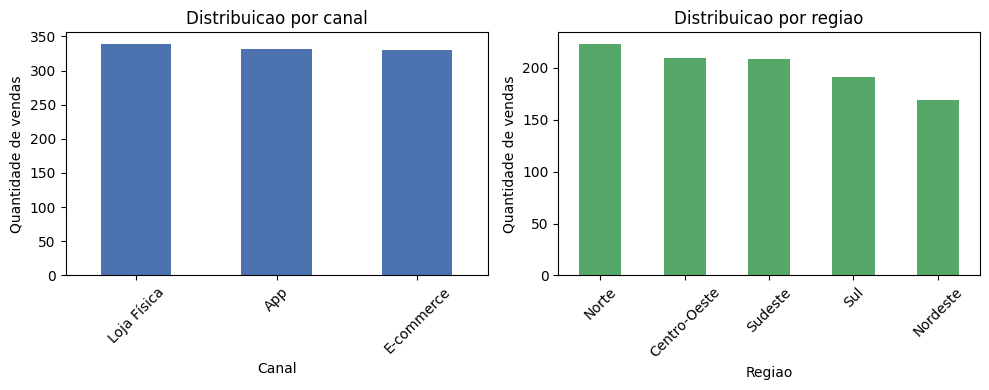

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df["canal_venda"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribuicao por canal")
axes[0].set_xlabel("Canal")
axes[0].set_ylabel("Quantidade de vendas")
axes[0].tick_params(axis="x", rotation=45)

df["regiao"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Distribuicao por regiao")
axes[1].set_xlabel("Regiao")
axes[1].set_ylabel("Quantidade de vendas")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretacao**
- Mostra os canais/regioes com maior volume de vendas.
- Diferencas grandes sugerem foco comercial ou oportunidades de expansao.

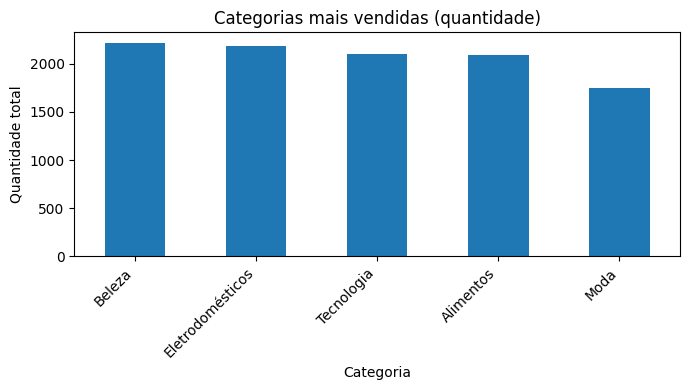

In [5]:
categorias = (
    df.groupby("categoria_produto")
    .agg(
        quantidade_total=("quantidade", "sum"),
        faturamento_total=("valor_total", "sum"),
        lucro_total=("lucro", "sum"),
        margem_media=("margem_lucro", "mean"),
    )
    .sort_values("quantidade_total", ascending=False)
)

categorias

categorias["quantidade_total"].plot(kind="bar", figsize=(7, 4))
plt.title("Categorias mais vendidas (quantidade)")
plt.xlabel("Categoria")
plt.ylabel("Quantidade total")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Interpretacao**
- As primeiras categorias concentram maior volume de vendas.
- A margem media indica eficiencia: categoria com margem alta gera mais lucro por real vendido.

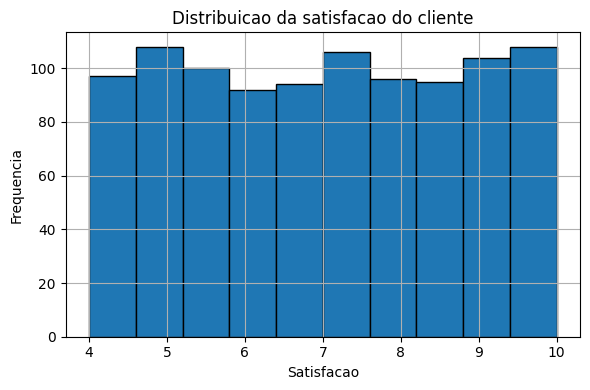

In [6]:
plt.figure(figsize=(6, 4))
df["satisfacao_cliente"].hist(bins=10, edgecolor="black")
plt.title("Distribuicao da satisfacao do cliente")
plt.xlabel("Satisfacao")
plt.ylabel("Frequencia")
plt.tight_layout()
plt.show()

**Interpretacao**
- Concentra a percepcao dos clientes em faixas de satisfacao.
- Assimetria indica polarizacao entre clientes satisfeitos e insatisfeitos.

## Analise diagnostica

Objetivo: investigar por que ocorrem variacoes nas vendas e no lucro.

In [7]:
variaveis_numericas = [
    "quantidade",
    "preco_unitario",
    "valor_total",
    "custo_total",
    "satisfacao_cliente",
    "lucro",
    "margem_lucro",
]

corr_lucro = df[variaveis_numericas].corr()["lucro"].sort_values(ascending=False)
corr_lucro

lucro                 1.00
valor_total           0.94
custo_total           0.86
preco_unitario        0.65
quantidade            0.57
margem_lucro          0.25
satisfacao_cliente   -0.03
Name: lucro, dtype: float64

**Interpretacao**
- Correlacoes positivas indicam variaveis associadas ao aumento do lucro.
- Correlacoes negativas sugerem fatores que reduzem o lucro.

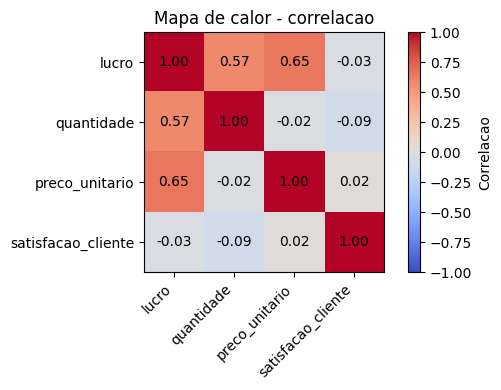

In [8]:
corr_heat = df[["lucro", "quantidade", "preco_unitario", "satisfacao_cliente"]].corr()

plt.figure(figsize=(6, 4))
plt.imshow(corr_heat, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlacao")

plt.xticks(range(len(corr_heat.columns)), corr_heat.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_heat.columns)), corr_heat.columns)

for i in range(len(corr_heat.columns)):
    for j in range(len(corr_heat.columns)):
        plt.text(j, i, f"{corr_heat.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Mapa de calor - correlacao")
plt.tight_layout()
plt.show()

**Interpretacao**
- O mapa de calor resume a forca e direcao das relacoes entre as variaveis.
- Valores proximos de 1 ou -1 indicam relacoes mais fortes.

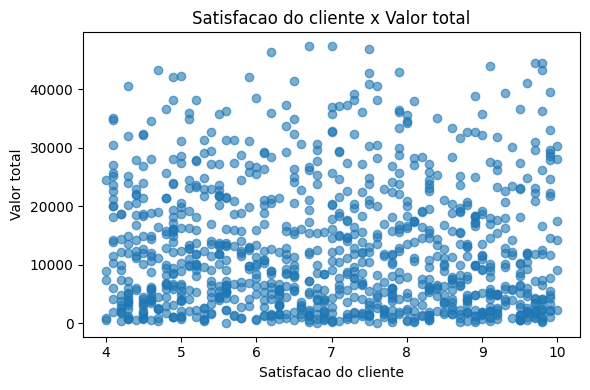

In [9]:
plt.figure(figsize=(6, 4))
plt.scatter(df["satisfacao_cliente"], df["valor_total"], alpha=0.6)
plt.title("Satisfacao do cliente x Valor total")
plt.xlabel("Satisfacao do cliente")
plt.ylabel("Valor total")
plt.tight_layout()
plt.show()

**Interpretacao**
- Ajuda a visualizar se vendas de maior valor estão associadas a maior satisfacao.
- Uma nuvem dispersa indica pouca relacao direta entre as variaveis.

## 5 Porques

**Problema observado:** lucro varia bastante entre vendas e canais.

1. **Por que** o lucro varia tanto?  
   Porque o valor total e o custo total mudam muito entre produtos e campanhas.
2. **Por que** valor e custo mudam tanto?  
   Porque cada categoria tem precos, quantidades e descontos diferentes por canal.
3. **Por que** os descontos e precos variam por canal?  
   Porque campanhas promocionais sao aplicadas de forma desigual entre canais e regioes.
4. **Por que** as campanhas sao desiguais?  
   Porque a estrategia de marketing prioriza canais com maior volume e nao otimiza margem.
5. **Por que** a estrategia nao otimiza margem?  
   Porque ainda falta monitorar margem por categoria/canal para ajustar precos e campanhas.